# Verify BigEarthNet-S2 DataLoader with Real Data

**Checklist:**
1. Import & scan dataset
2. Check dataset size & splits
3. Load single sample — verify shape, dtype, value range
4. Visualize RGB composite
5. Class distribution
6. DataLoader batch test
7. Band statistics

In [1]:
import sys, os, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
import logging

logging.basicConfig(level=logging.INFO)

from src.datasets.bigearth_loader import (
    BigEarthNetDataset,
    build_bigearth_subsets,
    build_bigearth_dataloaders,
    extract_rgb_bands,
    BIGEARTH_BANDS,
    NUM_BANDS,
    TARGET_SIZE,
    TOP10_CLASSES,
)

# === CONFIGURE THIS PATH ===
BIGEARTH_ROOT = os.path.join(PROJECT_ROOT, "data", "BigEarthNetS2")
print(f"BigEarthNet root: {BIGEARTH_ROOT}")
print(f"Exists: {os.path.isdir(BIGEARTH_ROOT)}")

BigEarthNet root: /Users/tienesng06/Desktop/ACIVS_ThayBach/data/BigEarthNetS2
Exists: True


## 1. Load Dataset (all split, limited samples for speed)

In [2]:
# Load a small subset first to verify quickly
# Increase max_samples once verified
t0 = time.time()
ds = BigEarthNetDataset(
    root=BIGEARTH_ROOT,
    split="all",
    max_samples=500,       # small subset for quick verify
    normalize=True,
    use_cache=False,
    remove_snow_cloud_shadow=True,
)
t1 = time.time()
print(f"\nDataset loaded in {t1-t0:.2f}s")
print(f"Total samples: {len(ds)}")
print(f"Bands: {ds.band_names} ({ds.num_bands})")
print(f"Classes: {ds.num_classes}")

INFO:src.datasets.bigearth_loader:Scanning BigEarthNet-S2 patches from /Users/tienesng06/Desktop/ACIVS_ThayBach/data/BigEarthNetS2 ...
INFO:src.datasets.bigearth_loader:  No *_labels_metadata.json found. Trying v2/TIF-only scan...
INFO:src.datasets.bigearth_loader:  Detected BigEarthNet v2 format (59550 B02.tif files).
INFO:src.datasets.bigearth_loader:Found 59550 valid patches (before subset/split).
INFO:src.datasets.bigearth_loader:Split 'all' contains 500 samples.



Dataset loaded in 54.39s
Total samples: 500
Bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12'] (12)
Classes: 10


## 2. Check Splits

In [3]:
subsets = build_bigearth_subsets(
    root=BIGEARTH_ROOT,
    max_samples=500,
    query_size=50,
    gallery_size=100,
    remove_snow_cloud_shadow=True,
)

for name, sub_ds in subsets.items():
    print(f"  {name:>10s}: {len(sub_ds):>6d} samples")

total = sum(len(s) for s in subsets.values())
print(f"  {'total':>10s}: {total:>6d}")

INFO:src.datasets.bigearth_loader:Scanning BigEarthNet-S2 patches from /Users/tienesng06/Desktop/ACIVS_ThayBach/data/BigEarthNetS2 ...
INFO:src.datasets.bigearth_loader:  No *_labels_metadata.json found. Trying v2/TIF-only scan...
INFO:src.datasets.bigearth_loader:  Detected BigEarthNet v2 format (59550 B02.tif files).
INFO:src.datasets.bigearth_loader:Found 59550 valid patches (before subset/split).
INFO:src.datasets.bigearth_loader:Split 'train' contains 350 samples.
INFO:src.datasets.bigearth_loader:Scanning BigEarthNet-S2 patches from /Users/tienesng06/Desktop/ACIVS_ThayBach/data/BigEarthNetS2 ...
INFO:src.datasets.bigearth_loader:  No *_labels_metadata.json found. Trying v2/TIF-only scan...
INFO:src.datasets.bigearth_loader:  Detected BigEarthNet v2 format (59550 B02.tif files).
INFO:src.datasets.bigearth_loader:Found 59550 valid patches (before subset/split).
INFO:src.datasets.bigearth_loader:Split 'query' contains 50 samples.
INFO:src.datasets.bigearth_loader:Scanning BigEarthNe

       train:    350 samples
       query:     50 samples
     gallery:    100 samples
       total:    500


## 3. Load Single Sample — Shape, Dtype, Range

In [4]:
sample = ds[0]

print("Keys:", list(sample.keys()))
print(f"\nimage shape  : {sample['image'].shape}")
print(f"image dtype  : {sample['image'].dtype}")
print(f"image min    : {sample['image'].min():.4f}")
print(f"image max    : {sample['image'].max():.4f}")
print(f"image mean   : {sample['image'].mean():.4f}")
print(f"\nlabels shape : {sample['labels'].shape}")
print(f"labels       : {sample['labels']}")
print(f"label_names  : {sample['label_names']}")
print(f"text         : {sample['text']}")
print(f"patch_name   : {sample['patch_name']}")

# Assertions
assert sample['image'].shape == (NUM_BANDS, TARGET_SIZE, TARGET_SIZE), "Wrong shape!"
assert sample['image'].dtype == torch.float32, "Wrong dtype!"
assert sample['image'].min() >= 0.0, "Values below 0!"
assert sample['image'].max() <= 1.0, "Values above 1!"
assert sample['labels'].shape == (len(TOP10_CLASSES),), "Wrong label shape!"
print("\nSingle sample verification passed!")

Keys: ['image', 'labels', 'label_names', 'text', 'patch_name', 'index']

image shape  : torch.Size([12, 120, 120])
image dtype  : torch.float32
image min    : 0.0027
image max    : 0.3598
image mean   : 0.1123

labels shape : torch.Size([10])
labels       : tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
label_names  : []
text         : A satellite image of .
patch_name   : S2A_MSIL2A_20171104T095201_N9999_R079_T33TXN_03_78

Single sample verification passed!


## 4. Visualize RGB Composite

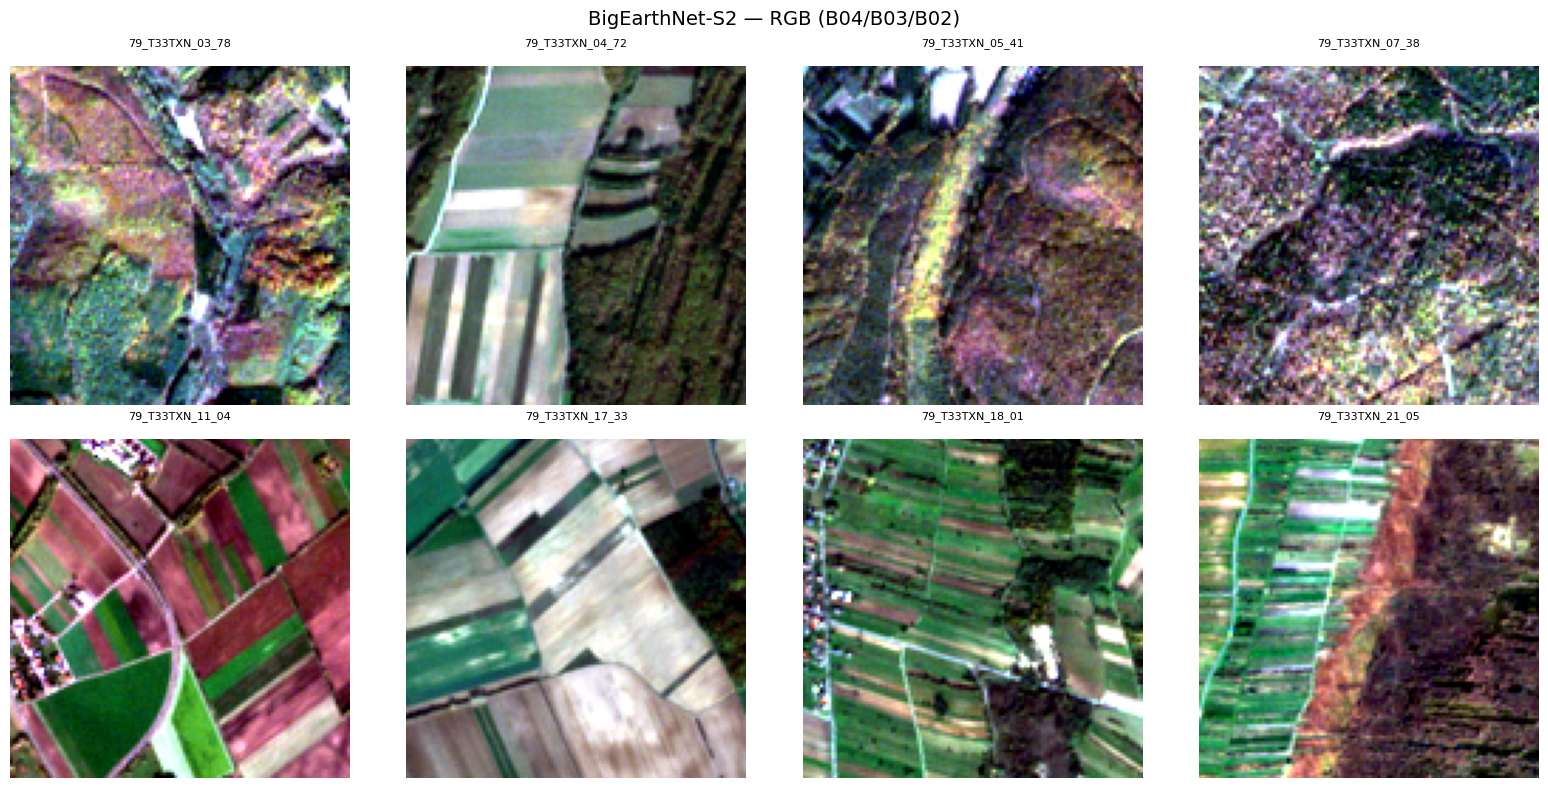

In [5]:
# Show first 8 samples as RGB
n_show = min(8, len(ds))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    sample = ds[i]
    rgb = extract_rgb_bands(sample['image'])  # (3, 120, 120)
    # Normalize to [0,1] for display — apply simple contrast stretch
    rgb_np = rgb.numpy().transpose(1, 2, 0)  # (120, 120, 3)
    # Contrast stretch per channel
    for ch in range(3):
        lo, hi = np.percentile(rgb_np[:,:,ch], [2, 98])
        if hi > lo:
            rgb_np[:,:,ch] = np.clip((rgb_np[:,:,ch] - lo) / (hi - lo), 0, 1)
    
    axes[i].imshow(rgb_np)
    labels_str = ', '.join(sample['label_names'][:2])  # show first 2
    axes[i].set_title(f"{sample['patch_name'][-15:]}\n{labels_str}", fontsize=8)
    axes[i].axis('off')

# Hide unused axes
for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle('BigEarthNet-S2 — RGB (B04/B03/B02)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Class Distribution

In [6]:
dist = ds.get_class_distribution()

classes = list(dist.keys())
counts = list(dist.values())
total_labels = sum(counts)

if total_labels == 0:
    print('⚠️  BigEarthNet v2 format — no label metadata available.')
    print('   Class distribution is empty (all counts = 0).')
    print('   This is expected for v2 dataset without separate label files.')
else:
    # Short labels for display
    short_labels = [c[:30] + '...' if len(c) > 30 else c for c in classes]

    fig, ax = plt.subplots(figsize=(16, 7))
    bars = ax.barh(range(len(classes)), counts, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(short_labels, fontsize=10)
    ax.set_xlabel('Count', fontsize=11)
    ax.set_title(f'Class Distribution (n={len(ds)} samples, multi-label)', fontsize=13)
    ax.invert_yaxis()

    # Annotate
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + max(counts)*0.01,
                bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=10)

    plt.subplots_adjust(left=0.30)
    plt.show()

    print('\nClass distribution:')
    for cls, cnt in dist.items():
        print(f'  {cls:60s}: {cnt:>5d}')


⚠️  BigEarthNet v2 format — no label metadata available.
   Class distribution is empty (all counts = 0).
   This is expected for v2 dataset without separate label files.


## 6. DataLoader Batch Test

In [9]:
from torch.utils.data import DataLoader

loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)

t0 = time.time()
batch_count = 0
total_samples = 0

for batch in loader:
    images = batch['image']
    labels = batch['labels']
    batch_count += 1
    total_samples += images.shape[0]
    
    if batch_count == 1:
        print(f"First batch:")
        print(f"  images: {images.shape}, dtype={images.dtype}")
        print(f"  labels: {labels.shape}, dtype={labels.dtype}")
        print(f"  patch_names: {batch['patch_name'][:3]}...")
    
    if batch_count >= 5:  # only check first 5 batches for speed
        break

t1 = time.time()
print(f"\nLoaded {batch_count} batches ({total_samples} samples) in {t1-t0:.2f}s")
print(f"Avg time per batch: {(t1-t0)/batch_count*1000:.1f} ms")
print(f"\n DataLoader batch test passed!")

First batch:
  images: torch.Size([16, 12, 120, 120]), dtype=torch.float32
  labels: torch.Size([16, 10]), dtype=torch.float32
  patch_names: ['S2A_MSIL2A_20171104T095201_N9999_R079_T33TXN_03_78', 'S2A_MSIL2A_20171104T095201_N9999_R079_T33TXN_04_72', 'S2A_MSIL2A_20171104T095201_N9999_R079_T33TXN_05_41']...

Loaded 5 batches (80 samples) in 0.72s
Avg time per batch: 143.7 ms

 DataLoader batch test passed!


## 7. Band Statistics (first 50 samples)

Band statistics (first 50 samples, normalized [0,1]):
  Band      Mean       Std       Min       Max
---------------------------------------------
   B01    0.0370    0.0239    0.0001    0.3169
   B02    0.0408    0.0337    0.0001    0.9408
   B03    0.0667    0.0399    0.0001    1.0000
   B04    0.0744    0.0500    0.0001    1.0000
   B05    0.1112    0.0462    0.0008    0.7175
   B06    0.1796    0.0578    0.0025    0.7897
   B07    0.2020    0.0624    0.0035    0.8736
   B08    0.2189    0.0723    0.0034    1.0000
   B8A    0.2244    0.0637    0.0038    0.9063
   B09    0.2269    0.0540    0.0095    0.5884
   B11    0.2117    0.0748    0.0124    1.0000
   B12    0.1446    0.0694    0.0077    1.0000


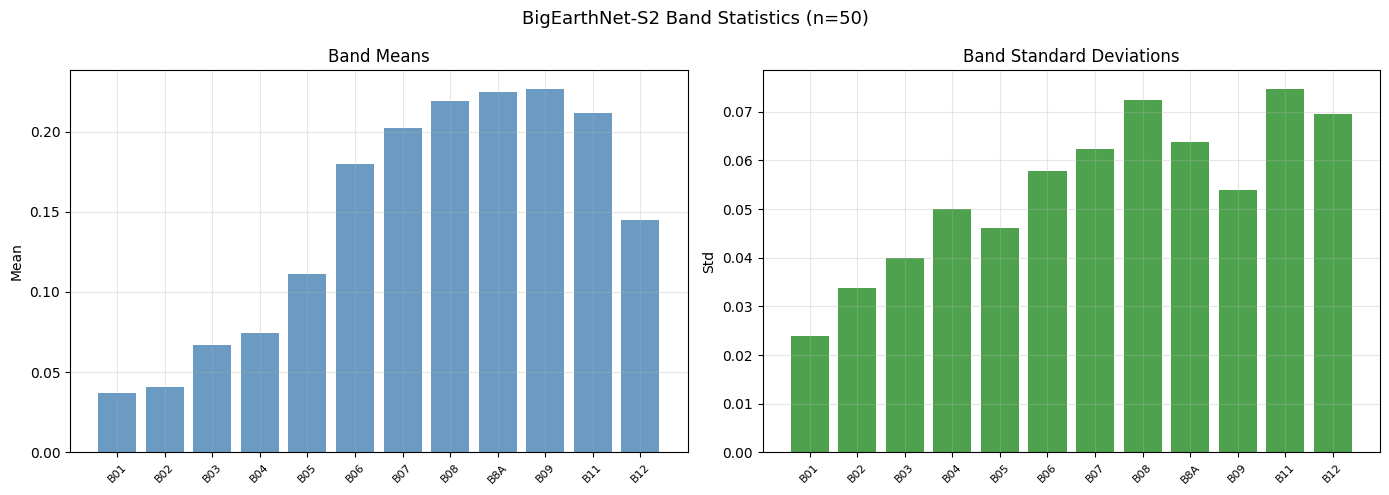

In [10]:
n_stat = min(50, len(ds))
all_images = torch.stack([ds[i]['image'] for i in range(n_stat)])  # (N, 12, 120, 120)

print(f"Band statistics (first {n_stat} samples, normalized [0,1]):")
print(f"{'Band':>6s}  {'Mean':>8s}  {'Std':>8s}  {'Min':>8s}  {'Max':>8s}")
print("-" * 45)

means = []
stds = []
for i, band_name in enumerate(BIGEARTH_BANDS):
    band = all_images[:, i, :, :]
    m = band.mean().item()
    s = band.std().item()
    lo = band.min().item()
    hi = band.max().item()
    means.append(m)
    stds.append(s)
    print(f"{band_name:>6s}  {m:>8.4f}  {s:>8.4f}  {lo:>8.4f}  {hi:>8.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(BIGEARTH_BANDS))
ax1.bar(x, means, color='steelblue', alpha=0.8)
ax1.set_xticks(list(x))
ax1.set_xticklabels(BIGEARTH_BANDS, rotation=45, fontsize=8)
ax1.set_ylabel('Mean')
ax1.set_title('Band Means')
ax1.grid(True, alpha=0.3)

ax2.bar(x, stds, color='forestgreen', alpha=0.8)
ax2.set_xticks(list(x))
ax2.set_xticklabels(BIGEARTH_BANDS, rotation=45, fontsize=8)
ax2.set_ylabel('Std')
ax2.set_title('Band Standard Deviations')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'BigEarthNet-S2 Band Statistics (n={n_stat})', fontsize=13)
plt.tight_layout()
plt.show()